# Build an LSTM Model Across All Tickers

This notebook trains one pooled LSTM return-regression model using every ticker in `core.tickers`. The goal is to test whether one model can learn patterns that generalise across stocks and sectors.

The model uses a 30-day input window and predicts the 5-trading-day return after the prediction date. Predicted returns are converted back into target close prices for MAE, RMSE, and MAPE evaluation.

In [ ]:
import gc
import sys
from pathlib import Path

# Add the backend folder to the path so this notebook can reuse the shared project code.
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the same feature function and ticker list as the other LSTM notebooks.
from core.fetch_data import SELECTED_FEATURE_COLS, get_ticker_features
from core.lstm_helpers import (
    build_lstm_model,
    inverse_scale_predictions,
    regression_metrics,
)
from core.lstm_helpers import (
    build_sector_data as build_lstm_dataset,
)
from core.tickers import TICKER_GROUPS, TICKERS
from tensorflow import keras

## 1. Configuration

In [3]:
# Start the raw feature download before the model period.
# This gives the moving averages enough warm-up data before 2022.
FEATURE_START = "2021-10-01"

# Keep the train, validation, and test periods separate by date.
# This makes the test period a clean final check on 2025 data.
TRAIN_START = "2022-01-01"
TRAIN_MODEL_END = "2023-12-31"
VALIDATION_START = "2024-01-01"
VALIDATION_END = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

# Download past 2025 because a late-2025 row still needs 5 future trading days.
DOWNLOAD_END = "2026-01-10"

# Use a 30-day input window to predict the 5-trading-day return.
FORECAST_HORIZON = 5
WINDOW_SIZE = 30

# These settings control the model training loop.
MAX_EPOCHS = 30
BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42

# Save the pooled model separately from the single-ticker and sector models.
MODEL_DIR = Path("../trained_models/lstm_all_tickers_return_regression")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Use every ticker from tickers.py once.
FEATURE_COLS = list(dict.fromkeys(SELECTED_FEATURE_COLS))
ALL_TICKERS = list(dict.fromkeys(TICKERS))
TICKER_TO_SECTOR = {
    ticker: sector for sector, tickers in TICKER_GROUPS.items() for ticker in tickers
}

print(f"{len(ALL_TICKERS)} tickers")
print(f"{len(TICKER_GROUPS)} sectors")
print(f"{len(FEATURE_COLS)} features per day, {WINDOW_SIZE}-day sequences")
print(f"Forecast target: {FORECAST_HORIZON}-trading-day return")

99 tickers
9 sectors
18 features per day, 30-day sequences
Forecast target: 5-trading-day return


## 2. Load Ticker Features

In [4]:
# Calculate the features once per ticker so the pooled model uses one shared source dataset.
ticker_features = {}

for ticker in ALL_TICKERS:
    df = get_ticker_features(
        ticker=ticker,
        start=FEATURE_START,
        end=DOWNLOAD_END,
        smooth_outliers=True,
    )

    # Skip tickers that cannot create one complete sequence and one future target.
    required_rows = WINDOW_SIZE + FORECAST_HORIZON + 1
    if df.empty or len(df) < required_rows:
        print(f"{ticker}: skipped (only {len(df)} rows)")
        continue

    ticker_features[ticker] = df
    print(f"{ticker}: {len(df)} rows ({df.index[0].date()} to {df.index[-1].date()})")

print(f"Loaded {len(ticker_features)} of {len(ALL_TICKERS)} requested tickers.")

AAPL: 1024 rows (2021-12-10 to 2026-01-09)
MSFT: 1024 rows (2021-12-10 to 2026-01-09)
GOOGL: 1024 rows (2021-12-10 to 2026-01-09)
GOOG: 1024 rows (2021-12-10 to 2026-01-09)
AMZN: 1024 rows (2021-12-10 to 2026-01-09)
META: 1024 rows (2021-12-10 to 2026-01-09)
NVDA: 1024 rows (2021-12-10 to 2026-01-09)
TSLA: 1024 rows (2021-12-10 to 2026-01-09)
AVGO: 1024 rows (2021-12-10 to 2026-01-09)
ORCL: 1024 rows (2021-12-10 to 2026-01-09)
CRM: 1024 rows (2021-12-10 to 2026-01-09)
ADBE: 1024 rows (2021-12-10 to 2026-01-09)
AMD: 1024 rows (2021-12-10 to 2026-01-09)
INTC: 1024 rows (2021-12-10 to 2026-01-09)
CSCO: 1024 rows (2021-12-10 to 2026-01-09)
IBM: 1024 rows (2021-12-10 to 2026-01-09)
QCOM: 1024 rows (2021-12-10 to 2026-01-09)
TXN: 1024 rows (2021-12-10 to 2026-01-09)
NOW: 1024 rows (2021-12-10 to 2026-01-09)
INTU: 1024 rows (2021-12-10 to 2026-01-09)
ACN: 1024 rows (2021-12-10 to 2026-01-09)
DIS: 1024 rows (2021-12-10 to 2026-01-09)
NFLX: 1024 rows (2021-12-10 to 2026-01-09)
CMCSA: 1024 rows 

## 3. Build the Pooled Dataset

In [5]:
# Build one pooled dataset using every loaded ticker.
# The helper works with any ticker group; here the group is the full ticker list.
dataset = build_lstm_dataset(
    ALL_TICKERS,
    ticker_features,
    FEATURE_COLS,
    TRAIN_START,
    TRAIN_MODEL_END,
    VALIDATION_START,
    VALIDATION_END,
    TEST_START,
    TEST_END,
    WINDOW_SIZE,
    FORECAST_HORIZON,
)

if dataset is None:
    raise ValueError(
        "No valid pooled dataset could be built from the available tickers."
    )

print(f"Training samples: {len(dataset['train']['y'])}")
print(f"Validation samples: {len(dataset['validation']['y'])}")
print(f"Test samples: {len(dataset['test']['y'])}")
print(f"Tickers used: {len(dataset['tickers'])}")

Training samples: 47718
Validation samples: 24453
Test samples: 24750
Tickers used: 99


## 4. Train and Test the All-Tickers Model

In [ ]:
# Train one model across all tickers and sectors.
X_train = dataset["train"]["X"]
y_train = dataset["train"]["y_scaled"]
X_validation = dataset["validation"]["X"]
y_validation = dataset["validation"]["y_scaled"]
X_test = dataset["test"]["X"]
y_test = dataset["test"]["y"]
current_close_test = dataset["test"]["current_close"]
target_close_test = dataset["test"]["target_close"]

# Reset the model state so this run is independent of earlier notebook runs.
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_SEED)

model = build_lstm_model((WINDOW_SIZE, len(FEATURE_COLS)))

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

# Validation data controls early stopping. The test data is only used after training.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=0,
)

# Convert scaled return predictions back before calculating price metrics.
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred = inverse_scale_predictions(dataset["target_scaler"], y_pred_scaled)
naive_pred = np.zeros_like(y_test)

model_metrics = regression_metrics(y_pred, current_close_test, target_close_test)
naive_metrics = regression_metrics(naive_pred, current_close_test, target_close_test)

model_path = MODEL_DIR / f"all_tickers_{FORECAST_HORIZON}d_return.keras"
model.save(model_path)

result = {
    "model": "All tickers LSTM",
    "forecast_horizon": f"{FORECAST_HORIZON}d",
    "tickers": len(dataset["tickers"]),
    "train_samples": len(dataset["train"]["y"]),
    "validation_samples": len(dataset["validation"]["y"]),
    "test_samples": len(y_test),
    "naive_mae": naive_metrics["mae"],
    "mae": model_metrics["mae"],
    "mae_difference": naive_metrics["mae"] - model_metrics["mae"],
    "naive_rmse": naive_metrics["rmse"],
    "rmse": model_metrics["rmse"],
    "rmse_difference": naive_metrics["rmse"] - model_metrics["rmse"],
    "naive_mape": naive_metrics["mape"],
    "mape": model_metrics["mape"],
    "mape_difference": naive_metrics["mape"] - model_metrics["mape"],
    "epochs": len(history.history["loss"]),
    "model_path": str(model_path),
}
result["beats_naive"] = result["mae_difference"] > 0

results_df = pd.DataFrame([result])
metric_cols = [
    "naive_mae",
    "mae",
    "mae_difference",
    "naive_rmse",
    "rmse",
    "rmse_difference",
    "naive_mape",
    "mape",
    "mape_difference",
]
results_df[metric_cols] = results_df[metric_cols].round(4)

artifact = {
    "metadata": dataset["test"]["metadata"],
    "y_test": y_test,
    "y_pred": y_pred,
    "current_close": current_close_test,
    "target_close": target_close_test,
}

display(results_df)

del model
gc.collect()

,model,forecast_horizon,tickers,train_samples,validation_samples,test_samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference,epochs,model_path,beats_naive
0,All tickers LSTM,5d,99,47718,24453,24750,7.2539,7.2209,0.033,13.0948,13.0848,0.01,0.0314,0.0313,0.0001,15,../trained_models/lstm_all_tickers_return_regr...,True


1156

## 5. Build Prediction Rows

In [ ]:
prediction_rows = artifact["metadata"].copy()
prediction_rows["sector"] = prediction_rows["ticker"].map(TICKER_TO_SECTOR)
prediction_rows["actual_return"] = artifact["y_test"]
prediction_rows["predicted_return"] = artifact["y_pred"]
prediction_rows["current_close"] = artifact["current_close"]
prediction_rows["actual_close"] = artifact["target_close"]
prediction_rows["predicted_close"] = prediction_rows["current_close"] * (
    1 + prediction_rows["predicted_return"]
)

prediction_rows.head()

,ticker,prediction_date,target_date,sector,actual_return,predicted_return,current_close,actual_close,predicted_close
0,AAPL,2025-01-02,2025-01-10,Technology and communication services,-0.028706,0.003051,242.301926,235.346375,243.041260
1,AAPL,2025-01-03,2025-01-13,Technology and communication services,-0.036818,0.003051,241.815033,232.911896,242.552734
2,AAPL,2025-01-06,2025-01-14,Technology and communication services,-0.047837,0.003053,243.444611,231.799042,244.187744
3,AAPL,2025-01-07,2025-01-15,Technology and communication services,-0.017918,0.003056,240.672333,236.359879,241.407837
4,AAPL,2025-01-08,2025-01-16,Technology and communication services,-0.059497,0.003061,241.159241,226.810883,241.897324


In [8]:
# These summaries show whether the pooled model works broadly or only for specific groups.
def summarize_prediction_group(rows, group_col):
    summaries = []

    for group_name, group in rows.groupby(group_col):
        group_y_pred = group["predicted_return"].to_numpy()
        group_naive_pred = np.zeros(len(group), dtype=np.float32)
        group_current_close = group["current_close"].to_numpy()
        group_target_close = group["actual_close"].to_numpy()

        group_model_metrics = regression_metrics(
            group_y_pred,
            group_current_close,
            group_target_close,
        )
        group_naive_metrics = regression_metrics(
            group_naive_pred,
            group_current_close,
            group_target_close,
        )

        summaries.append(
            {
                group_col: group_name,
                "samples": len(group),
                "naive_mae": group_naive_metrics["mae"],
                "mae": group_model_metrics["mae"],
                "mae_difference": group_naive_metrics["mae"]
                - group_model_metrics["mae"],
                "naive_rmse": group_naive_metrics["rmse"],
                "rmse": group_model_metrics["rmse"],
                "rmse_difference": group_naive_metrics["rmse"]
                - group_model_metrics["rmse"],
                "naive_mape": group_naive_metrics["mape"],
                "mape": group_model_metrics["mape"],
                "mape_difference": group_naive_metrics["mape"]
                - group_model_metrics["mape"],
            }
        )

    summary_df = pd.DataFrame(summaries)
    summary_metric_cols = [
        "naive_mae",
        "mae",
        "mae_difference",
        "naive_rmse",
        "rmse",
        "rmse_difference",
        "naive_mape",
        "mape",
        "mape_difference",
    ]
    summary_df[summary_metric_cols] = summary_df[summary_metric_cols].round(4)

    return summary_df.sort_values("mae_difference", ascending=False)

## 6. Compare Results by Sector

In [9]:
# Sector-level results show whether the all-ticker model generalises across sectors.
sector_results_df = summarize_prediction_group(prediction_rows, "sector")
sector_results_df

,sector,samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference
2,Financials,3250,9.3506,9.2188,0.1318,15.3984,15.3206,0.0779,0.0282,0.0278,0.0004
4,Industrials,2750,7.7983,7.7322,0.0661,11.4818,11.4268,0.0550,0.0310,0.0307,0.0002
5,Materials,1250,5.6700,5.6303,0.0396,8.4484,8.4745,-0.0261,0.0322,0.0319,0.0003
3,Healthcare,3500,9.0666,9.0356,0.0310,18.6301,18.6063,0.0238,0.0312,0.0311,0.0001
8,Utilities,1500,1.7302,1.7090,0.0212,2.4053,2.3965,0.0088,0.0213,0.0211,0.0002
1,Energy,1750,3.5235,3.5102,0.0133,5.0672,5.0660,0.0011,0.0328,0.0327,0.0001
7,Technology and communication services,6750,8.3373,8.3290,0.0083,13.5425,13.5567,-0.0142,0.0374,0.0375,-0.0000
6,Real estate,750,9.3489,9.3470,0.0019,16.6189,16.7450,-0.1261,0.0252,0.0252,0.0000
0,Consumer staples and discretionary,3250,5.1782,5.1981,-0.0198,9.7369,9.7631,-0.0262,0.0277,0.0278,-0.0001


## 7. Compare Results by Ticker

In [10]:
# Ticker-level results show which individual stocks benefit most from the pooled model.
ticker_results_df = summarize_prediction_group(prediction_rows, "ticker")
ticker_results_df

,ticker,samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference
53,LLY,250,38.7610,38.4055,0.3556,49.6615,49.4793,0.1822,0.0476,0.0472,0.0004
42,GS,250,22.5937,22.2612,0.3326,28.7385,28.3917,0.3468,0.0347,0.0343,0.0005
15,BLK,250,27.2439,26.9422,0.3016,34.7645,34.7157,0.0489,0.0276,0.0273,0.0003
56,MA,250,12.7373,12.4399,0.2974,16.5964,16.5486,0.0478,0.0233,0.0228,0.0005
50,JPM,250,7.2489,7.0138,0.2351,9.2623,9.1442,0.1182,0.0273,0.0265,0.0008
...,...,...,...,...,...,...,...,...,...,...,...
23,COST,250,22.0494,22.1297,-0.0803,29.5546,29.5936,-0.0390,0.0231,0.0233,-0.0001
47,INTU,250,18.7241,18.8064,-0.0823,25.1438,25.2066,-0.0628,0.0283,0.0285,-0.0002
48,ISRG,250,18.6137,18.7013,-0.0875,25.8761,25.8723,0.0038,0.0356,0.0358,-0.0002
88,TMO,250,15.5909,15.6952,-0.1044,21.6471,21.6326,0.0145,0.0314,0.0317,-0.0003


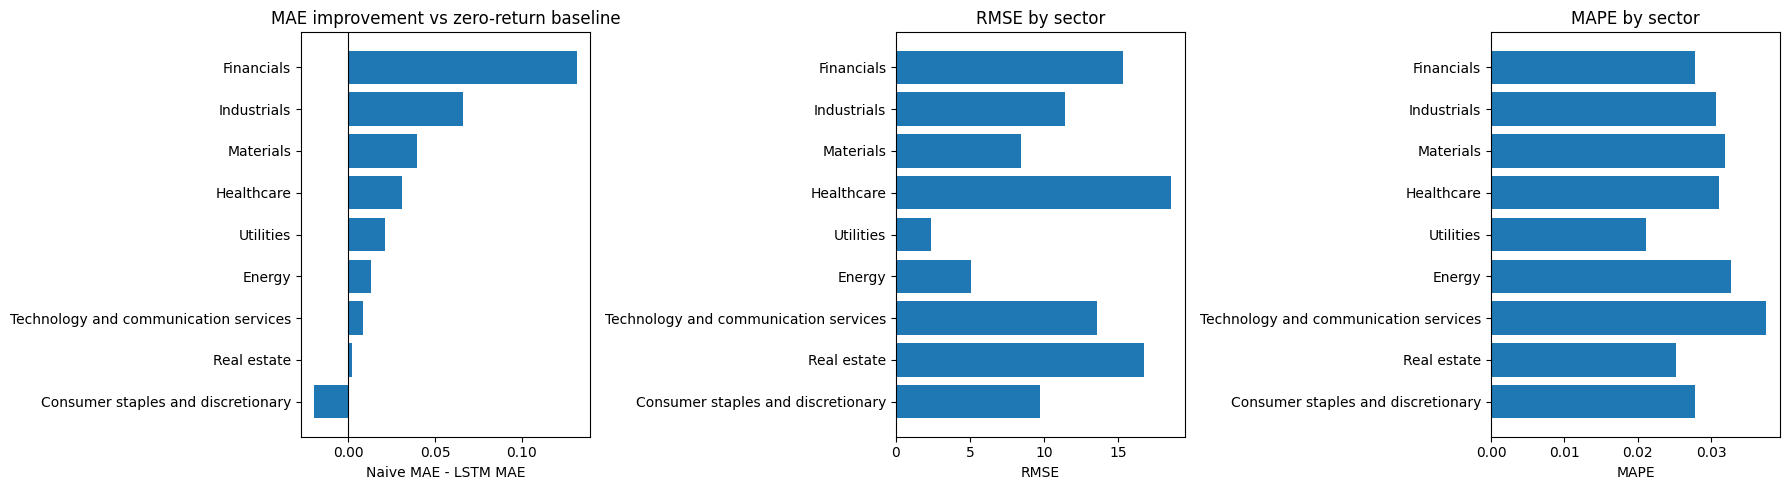

In [11]:
# Plot the sector results so strong and weak groups are easier to compare.
if not sector_results_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    plot_df = sector_results_df.sort_values("mae_difference", ascending=True)

    axes[0].barh(plot_df["sector"], plot_df["mae_difference"])
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_title("MAE improvement vs zero-return baseline")
    axes[0].set_xlabel("Naive MAE - LSTM MAE")

    axes[1].barh(plot_df["sector"], plot_df["rmse"])
    axes[1].set_title("RMSE by sector")
    axes[1].set_xlabel("RMSE")

    axes[2].barh(plot_df["sector"], plot_df["mape"])
    axes[2].set_title("MAPE by sector")
    axes[2].set_xlabel("MAPE")

    plt.tight_layout()
    plt.show()

## 8. Inspect Training History

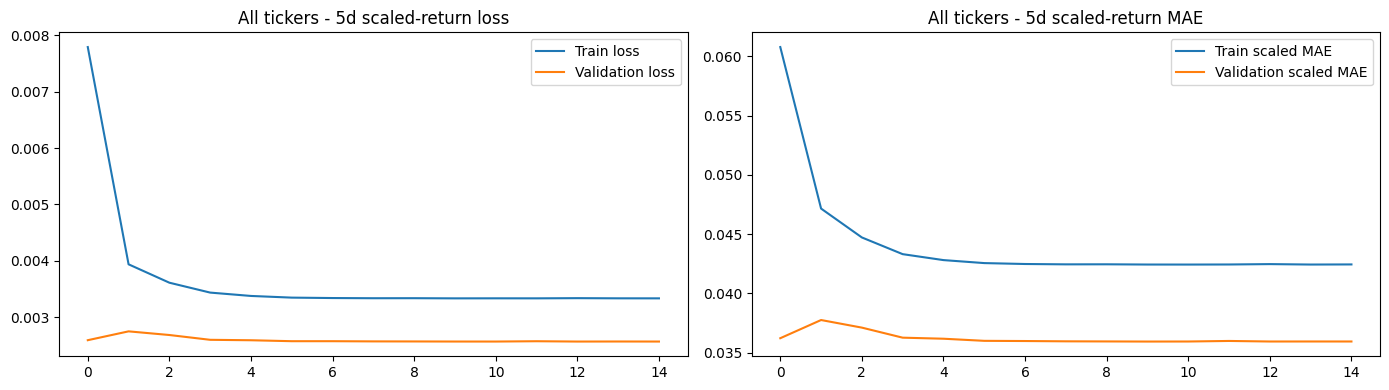

In [12]:
# Inspect the training history to check for overfitting.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# If validation loss rises while training loss falls, the model is overfitting.
axes[0].plot(history.history["loss"], label="Train loss")
axes[0].plot(history.history["val_loss"], label="Validation loss")
axes[0].set_title(f"All tickers - {FORECAST_HORIZON}d scaled-return loss")
axes[0].legend()

# This MAE is on the scaled return target, so use it mainly to inspect training behaviour.
axes[1].plot(history.history["mae"], label="Train scaled MAE")
axes[1].plot(history.history["val_mae"], label="Validation scaled MAE")
axes[1].set_title(f"All tickers - {FORECAST_HORIZON}d scaled-return MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Plot One Ticker Prediction

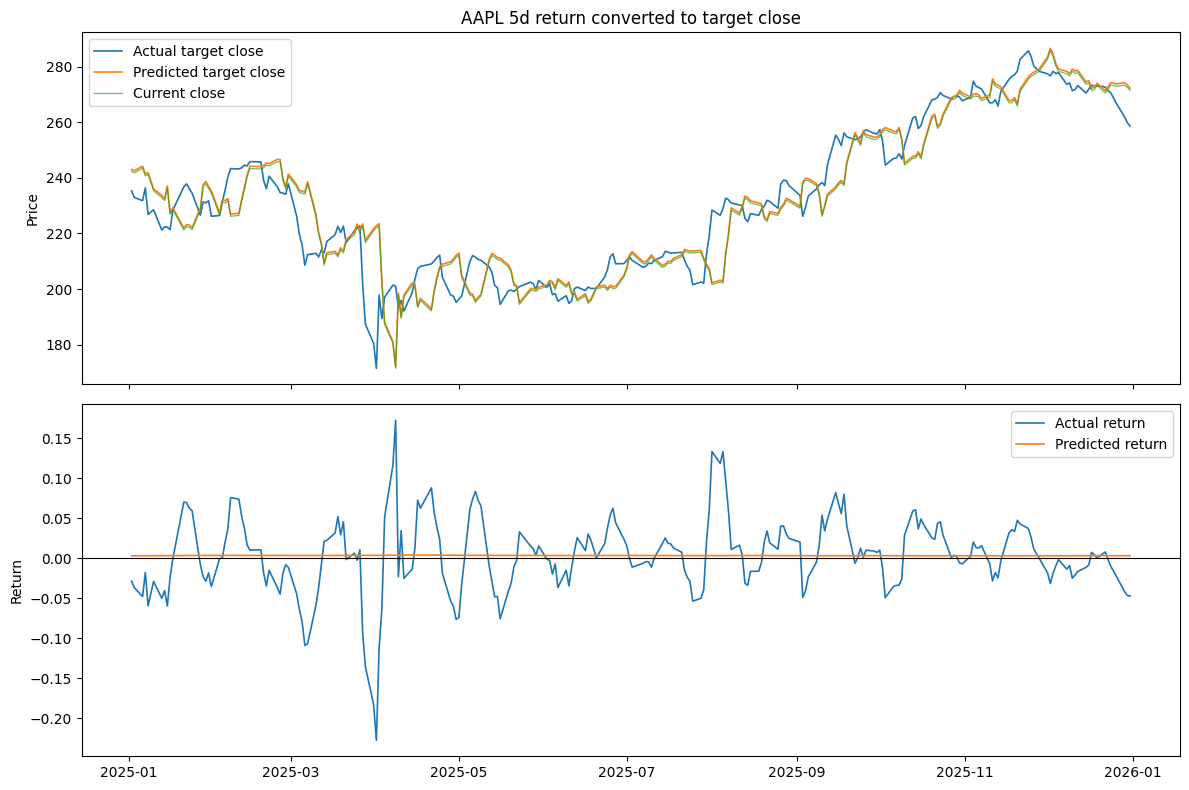

In [13]:
# Plot one ticker prediction to see whether the pooled model is lagging the actual price.
PLOT_TICKER = "AAPL"

if PLOT_TICKER not in set(prediction_rows["ticker"]):
    PLOT_TICKER = prediction_rows["ticker"].iloc[0]

plot_rows = prediction_rows[prediction_rows["ticker"] == PLOT_TICKER].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    plot_rows["prediction_date"],
    plot_rows["actual_close"],
    label="Actual target close",
    linewidth=1.2,
)
axes[0].plot(
    plot_rows["prediction_date"],
    plot_rows["predicted_close"],
    label="Predicted target close",
    linewidth=1.2,
)
axes[0].plot(
    plot_rows["prediction_date"],
    plot_rows["current_close"],
    label="Current close",
    linewidth=0.9,
    alpha=0.7,
)
axes[0].set_title(f"{PLOT_TICKER} {FORECAST_HORIZON}d return converted to target close")
axes[0].set_ylabel("Price")
axes[0].legend()

# The return chart shows whether prediction errors come from direction or size.
axes[1].plot(
    plot_rows["prediction_date"],
    plot_rows["actual_return"],
    label="Actual return",
    linewidth=1.2,
)
axes[1].plot(
    plot_rows["prediction_date"],
    plot_rows["predicted_return"],
    label="Predicted return",
    linewidth=1.2,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Return")
axes[1].legend()

plt.tight_layout()
plt.show()